In [ ]:
!pip install -q qiskit qiskit-aer matplotlib

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.6 MB/s eta 0:00:00


In [ ]:
# --- Exercise 1: Constant Function f(x) = 0 (Fixed) ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# 1. Initialize circuit
qc_easy = QuantumCircuit(2, 1)

# 2. State Preparation: |0> -> |+> for q0, |0> -> |-> for q1
qc_easy.x(1)
qc_easy.h(0)
qc_easy.h(1)
qc_easy.barrier()

# 3. Oracle for f(x) = 0 (Identity / no-op)
oracle_f0 = QuantumCircuit(2, name="Oracle_f0")
oracle_f0.id(0)
oracle_f0.id(1)

qc_easy.append(oracle_f0.to_gate(), [0, 1])
qc_easy.barrier()

# 4. Interference step on input qubit
qc_easy.h(0)

# 5. Measure the input qubit
qc_easy.measure(0, 0)

# Transpile to unroll custom gates into simulator-supported basis gates
t_qc_easy = transpile(qc_easy, simulator)
counts = simulator.run(t_qc_easy, shots=1024).result().get_counts()

print("Circuit diagram:")
print(qc_easy.draw('text'))
print(f"\nMeasurement Counts: {counts}")
print("Verification: Passed! Output is '0' (Constant)." if list(counts.keys()) == ['0'] else "Failed.")

Circuit diagram:
     ┌───┐      ░ ┌────────────┐ ░ ┌───┐┌─┐
q_0: ┤ H ├──────░─┤0           ├─░─┤ H ├┤M├
     ├───┤┌───┐ ░ │  Oracle_f0 │ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤1           ├─░───────╫─
     └───┘└───┘ ░ └────────────┘ ░       ║ 
c: 1/════════════════════════════════════╩═
                                         0 

Measurement Counts: {'0': 1024}
Verification: Passed! Output is '0' (Constant).


In [ ]:
# --- Exercise 2: Balanced Function f(x) = x ---
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# 1. Initialize circuit
qc_medium = QuantumCircuit(2, 1)

# 2. State Preparation: |0> -> |+> for q0, |0> -> |-> for q1
qc_medium.x(1)
qc_medium.h(0)
qc_medium.h(1)
qc_medium.barrier()

# 3. Oracle for f(x) = x (CNOT: control=0, target=1)
qc_medium.cx(0, 1)
qc_medium.barrier()

# 4. Interference step
qc_medium.h(0)

# 5. Measure the input qubit
qc_medium.measure(0, 0)

# Execute and display results
counts = simulator.run(qc_medium, shots=1024).result().get_counts()
print("Circuit diagram:")
print(qc_medium.draw('text'))
print(f"\nMeasurement Counts: {counts}")
print("Verification: Passed! Output is '1' (Balanced)." if list(counts.keys()) == ['1'] else "Failed.")

Circuit diagram:
     ┌───┐      ░       ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───■───░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌─┴─┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘ ░       ║ 
c: 1/═══════════════════════════╩═
                                0 

Measurement Counts: {'1': 1024}
Verification: Passed! Output is '1' (Balanced).


In [ ]:
# --- Exercise 3: Generic Oracle Selector (Fixed) ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()

def build_oracle(func_type: str) -> QuantumCircuit:
    oracle = QuantumCircuit(2, name=f"Oracle_{func_type}")

    if func_type == 'constant_0':
        pass
    elif func_type == 'constant_1':
        oracle.x(1)
    elif func_type == 'balanced_id':
        oracle.cx(0, 1)
    elif func_type == 'balanced_not':
        oracle.x(0)
        oracle.cx(0, 1)
        oracle.x(0)
    else:
        raise ValueError(f"Unknown function type: {func_type}")

    return oracle

def run_deutsch(func_type: str):
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.h(0)
    qc.h(1)

    # Append the custom oracle gate
    oracle = build_oracle(func_type)
    qc.append(oracle.to_gate(), [0, 1])

    qc.h(0)
    qc.measure(0, 0)

    # Transpile so AerSimulator understands the custom composite gate
    t_qc = transpile(qc, simulator)
    counts = simulator.run(t_qc, shots=1024).result().get_counts()

    measured_bit = list(counts.keys())[0]
    verdict = "Constant" if measured_bit == '0' else "Balanced"
    return counts, verdict

# Test all 4 functions
test_functions = ['constant_0', 'constant_1', 'balanced_id', 'balanced_not']

print(f"{'Function Type':<16} | {'Counts':<10} | {'Algorithm Decision':<12}")
print("-" * 46)
for fn in test_functions:
    counts, verdict = run_deutsch(fn)
    print(f"{fn:<16} | {str(counts):<10} | {verdict:<12}")

Function Type    | Counts     | Algorithm Decision
----------------------------------------------
constant_0       | {'0': 1024} | Constant    
constant_1       | {'0': 1024} | Constant    
balanced_id      | {'1': 1024} | Balanced    
balanced_not     | {'1': 1024} | Balanced    


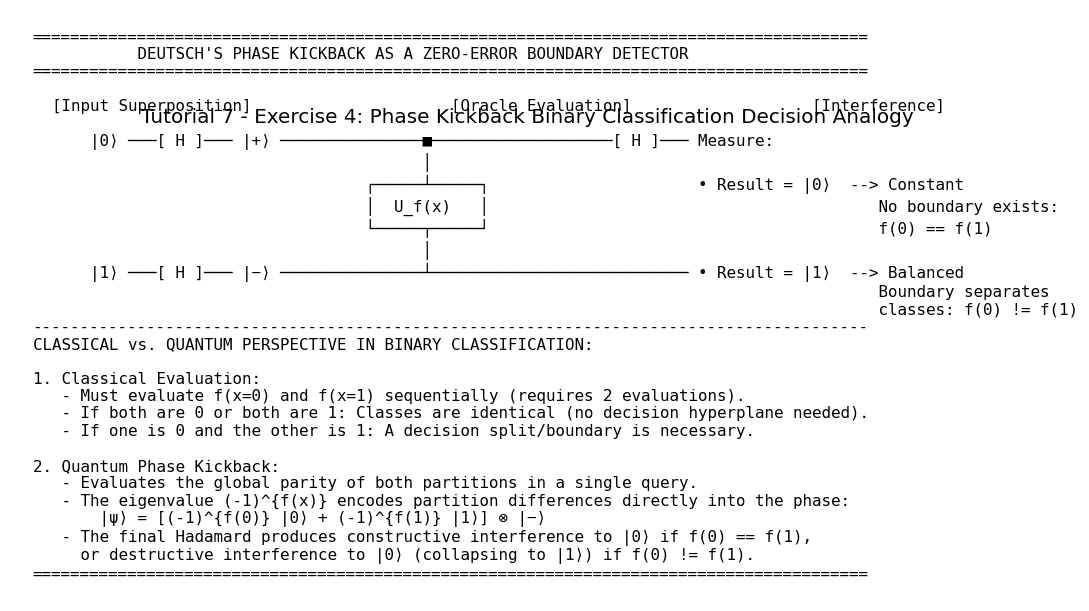

In [ ]:
# --- Exercise 4: Real-world Analogy (Binary Classification Decision) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
ax.axis('off')

# Render schematic diagram explaining the quantum decision process
schema = """
========================================================================================
           DEUTSCH'S PHASE KICKBACK AS A ZERO-ERROR BOUNDARY DETECTOR
========================================================================================

  [Input Superposition]                     [Oracle Evaluation]                   [Interference]

      |0⟩ ───[ H ]─── |+⟩ ───────────────■───────────────────[ H ]─── Measure:
                                         │
                                   ┌─────┴─────┐                      • Result = |0⟩  --> Constant
                                   │  U_f(x)   │                                         No boundary exists:
                                   └─────┬─────┘                                         f(0) == f(1)
                                         │
      |1⟩ ───[ H ]─── |−⟩ ───────────────┴─────────────────────────── • Result = |1⟩  --> Balanced
                                                                                         Boundary separates
                                                                                         classes: f(0) != f(1)
----------------------------------------------------------------------------------------
CLASSICAL vs. QUANTUM PERSPECTIVE IN BINARY CLASSIFICATION:

1. Classical Evaluation:
   - Must evaluate f(x=0) and f(x=1) sequentially (requires 2 evaluations).
   - If both are 0 or both are 1: Classes are identical (no decision hyperplane needed).
   - If one is 0 and the other is 1: A decision split/boundary is necessary.

2. Quantum Phase Kickback:
   - Evaluates the global parity of both partitions in a single query.
   - The eigenvalue (-1)^{f(x)} encodes partition differences directly into the phase:
       |ψ⟩ = [(-1)^{f(0)} |0⟩ + (-1)^{f(1)} |1⟩] ⊗ |−⟩
   - The final Hadamard produces constructive interference to |0⟩ if f(0) == f(1),
     or destructive interference to |0⟩ (collapsing to |1⟩) if f(0) != f(1).
========================================================================================
"""

ax.text(0.02, 0.5, schema, family='monospace', fontsize=9.5, verticalalignment='center')
plt.title("Tutorial 7 - Exercise 4: Phase Kickback Binary Classification Decision Analogy", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

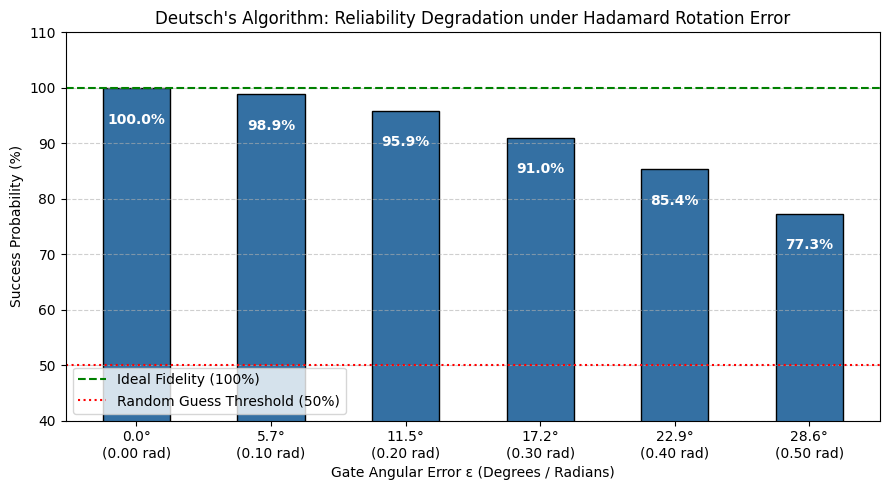

In [ ]:
# --- Exercise 5: Imperfect Hadamard Gate Error Analysis (Fixed) ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()

def imperfect_hadamard(epsilon):
    qc = QuantumCircuit(1, name=f"Noisy_H")
    qc.ry(np.pi / 2 + epsilon, 0)
    qc.z(0)
    return qc.to_gate()

epsilon_values = np.linspace(0.0, 0.5, 6)
success_rates = []
shots = 4096

for eps in epsilon_values:
    qc = QuantumCircuit(2, 1)
    qc.x(1)

    # Imperfect Hadamard on input
    qc.append(imperfect_hadamard(eps), [0])
    qc.h(1)

    # Balanced oracle: f(x) = x
    qc.cx(0, 1)

    # Imperfect Hadamard for interference
    qc.append(imperfect_hadamard(eps), [0])
    qc.measure(0, 0)

    # Transpile to unroll Noisy_H
    t_qc = transpile(qc, simulator)
    counts = simulator.run(t_qc, shots=shots).result().get_counts()

    success = counts.get('1', 0) / shots
    success_rates.append(success)

plt.figure(figsize=(9, 5))
bar_labels = [f"{np.degrees(e):.1f}°\n({e:.2f} rad)" for e in epsilon_values]
bars = plt.bar(bar_labels, [s * 100 for s in success_rates], color="#3470a3", edgecolor="black", width=0.5)

plt.axhline(y=100, color='green', linestyle='--', label='Ideal Fidelity (100%)')
plt.axhline(y=50, color='red', linestyle=':', label='Random Guess Threshold (50%)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval - 7, f"{yval:.1f}%", ha='center', va='bottom', color='white', fontweight='bold')

plt.title("Deutsch's Algorithm: Reliability Degradation under Hadamard Rotation Error", fontsize=12)
plt.xlabel("Gate Angular Error ε (Degrees / Radians)", fontsize=10)
plt.ylabel("Success Probability (%)", fontsize=10)
plt.ylim(40, 110)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()